# 03 - Sales & Revenue

Trends, growth, top products, and a forecast.

In [1]:
import sys; sys.path.append('../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from data_prep import clean_transactions, summarize
sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize']=(10,5)

In [2]:
# Load raw data (after placing online_retail_II.xlsx in ../data/raw/)
raw = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name=None)
df = pd.concat(raw.values(), ignore_index=True)
df = clean_transactions(df)
summarize(df)

{'rows': 805549,
 'customers': 5878,
 'invoices': 36969,
 'first_order': Timestamp('2009-12-01 07:45:00'),
 'last_order': Timestamp('2011-12-09 12:50:00'),
 'total_revenue': np.float64(17743429.18)}

## Month-over-month growth

In [3]:
m = df.set_index('invoice_date').resample('M').agg(revenue=('revenue','sum'),
        orders=('invoice','nunique'))
m['mom_growth_%'] = m['revenue'].pct_change()*100
m['aov'] = m['revenue']/m['orders']
m.round(2).tail(12)

/var/folders/kt/cvwk10vd15g2c057rj__047h0000gn/T/ipykernel_8476/1925603130.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  m = df.set_index('invoice_date').resample('M').agg(revenue=('revenue','sum'),


,revenue,orders,mom_growth_%,aov
invoice_date,,,,
2011-01-31,569445.04,987,-35.63,576.95
2011-02-28,447137.35,997,-21.48,448.48
2011-03-31,595500.76,1321,33.18,450.80
2011-04-30,469200.36,1149,-21.21,408.36
2011-05-31,678594.56,1555,44.63,436.40
2011-06-30,661213.69,1393,-2.56,474.67
2011-07-31,600091.01,1331,-9.24,450.86
2011-08-31,645343.90,1280,7.54,504.17
2011-09-30,952838.38,1755,47.65,542.93


## Top products

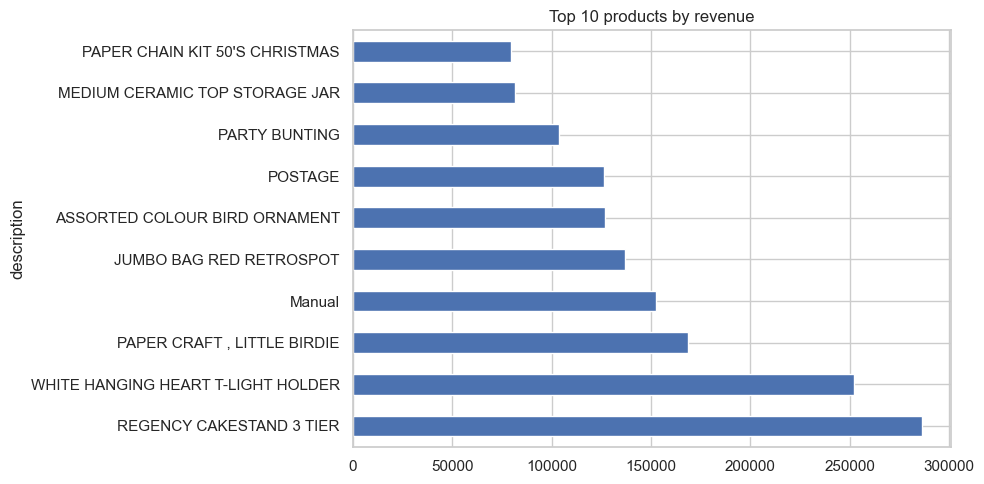

In [4]:
(df.groupby('description')['revenue'].sum().sort_values(ascending=False)
   .head(10).plot.barh(title='Top 10 products by revenue'))
plt.tight_layout()

## Simple forecast (Prophet, optional)

In [5]:
try:
    from prophet import Prophet
    ts = m.reset_index()[['invoice_date','revenue']].rename(
         columns={'invoice_date':'ds','revenue':'y'})
    fc = Prophet().fit(ts)
    future = fc.make_future_dataframe(periods=3, freq='M')
    print(fc.predict(future)[['ds','yhat','yhat_lower','yhat_upper']].tail(6))
except ImportError:
    print('Install prophet to run the forecast: pip install prophet')

Install prophet to run the forecast: pip install prophet


> **Next:** `04_marketing_ltv.ipynb`